# 03 - Exploratory Data Analysis

## Project

MaternalRisk: Early Prediction of Gestational Diabetes Using Explainable Machine Learning

**Author:** Kristen Cranford

**Date:** July 2026

---

# Objective

The objective of this notebook is to explore the clinical and statistical characteristics of the processed dataset prior to feature engineering and model development.

The analysis investigates the distribution of predictor variables, relationships with gestational diabetes, and interactions among clinical features. Findings from this exploratory analysis will guide subsequent feature engineering and modeling decisions.

# Background

The dataset has undergone an initial data quality assessment and preprocessing strategy, resulting in a cleaned dataset suitable for exploratory analysis.

Exploratory data analysis (EDA) is used to better understand the characteristics of the patient population, identify meaningful relationships between predictors and gestational diabetes, and detect patterns that may influence model performance.

The goal of this notebook is not to draw causal conclusions, but to identify clinically relevant trends that warrant further investigation during model development.

# Workflow

This notebook follows the exploratory analysis workflow below:

1. Load the processed dataset.
2. Examine the target variable.
3. Explore individual predictor distributions.
4. Compare predictors across gestational diabetes outcomes.
5. Investigate relationships among predictors.
6. Summarize clinically relevant findings.
7. Identify implications for feature engineering and model development.

In [1]:
# Load Data
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = Path("../data/processed/gdm_clean.parquet")

df = pd.read_parquet(DATA_PATH)

df.head()

,Age,No of Pregnancy,Gestation in previous Pregnancy,BMI,HDL,Family History,unexplained prenetal loss,Large Child or Birth Default,PCOS,Sys BP,Dia BP,OGTT,Hemoglobin,Sedentary Lifestyle,Prediabetes,Class Label(GDM /Non GDM),Missing Count
0,22,2,1,NaN,55.0,0,0,0,0,102.0,69,NaN,12.0,0,0,0,2
1,26,2,1,NaN,53.0,0,0,0,0,101.0,63,NaN,12.4,0,0,0,2
2,29,1,0,NaN,50.0,0,0,0,0,118.0,79,NaN,14.3,0,0,0,2
3,28,2,1,NaN,51.0,0,0,0,0,99.0,70,NaN,15.0,0,0,0,2
4,21,2,1,NaN,52.0,0,0,0,0,116.0,65,NaN,15.0,0,0,0,2


## Investigation 1 — Target Variable

## Question

What is the distribution of the target variable?

In [2]:
target = "Class Label(GDM /Non GDM)"

counts = df[target].value_counts()

percentages = (
    df[target]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(counts)
display(percentages)

Class Label(GDM /Non GDM)
0    2153
1    1372
Name: count, dtype: int64

Class Label(GDM /Non GDM)
0    61.08
1    38.92
Name: proportion, dtype: float64

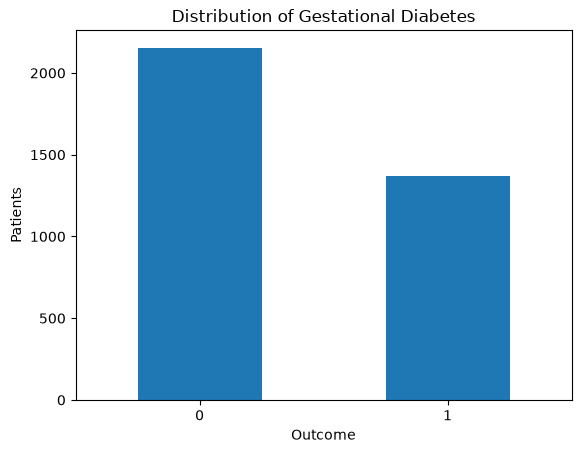

In [3]:
counts.plot(kind="bar")

plt.title("Distribution of Gestational Diabetes")
plt.xlabel("Outcome")
plt.ylabel("Patients")

plt.xticks(rotation=0)

plt.show()

## Interpretation

Approximately 39% of pregnancies were diagnosed with gestational diabetes, while 61% were classified as non-GDM. Although the classes are not perfectly balanced, the imbalance is moderate rather than extreme. Stratified sampling should therefore be used during train-test splitting to preserve class proportions, and model performance should be evaluated using metrics such as precision, recall, F1-score, and ROC-AUC in addition to overall accuracy.

## Key Finding 1 — Target Distribution

The dataset contains a moderate class imbalance, with approximately 39% of pregnancies diagnosed with gestational diabetes. This imbalance is not severe but should be considered during model development through stratified data splitting and evaluation using metrics beyond overall accuracy.

## Investigation 2 — Continuous Variables

## Question

What are the distributions of the continuous clinical variables?

Age


count    3525.000000
mean       32.581277
std         6.169107
min        20.000000
25%        28.000000
50%        32.000000
75%        37.000000
max        45.000000
Name: Age, dtype: float64

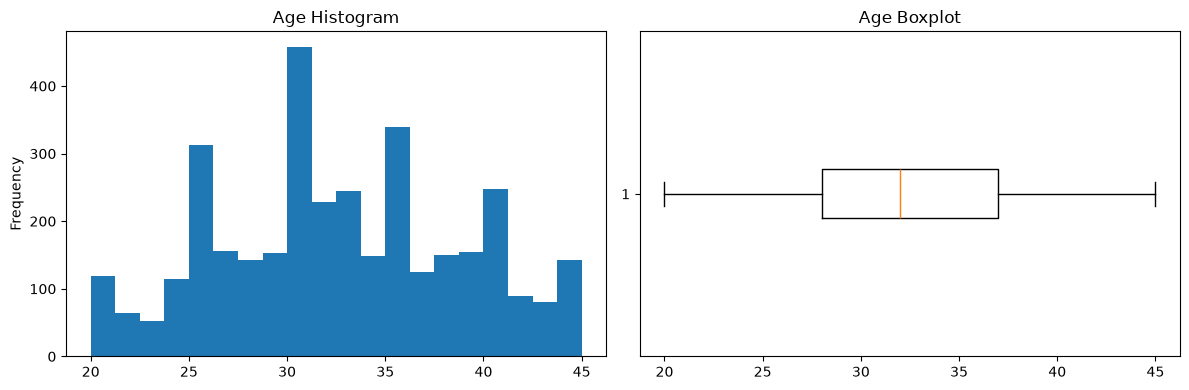

BMI


count    2444.000000
mean       27.854092
std         5.714737
min        13.300000
25%        24.400000
50%        27.500000
75%        31.000000
max        45.000000
Name: BMI, dtype: float64

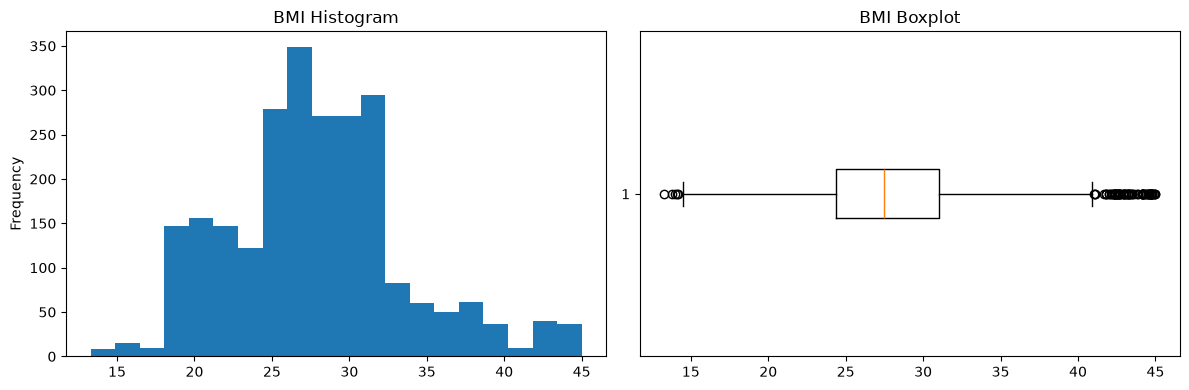

HDL


count    2524.000000
mean       46.471870
std        10.800813
min        15.000000
25%        42.000000
50%        49.000000
75%        55.000000
max        70.000000
Name: HDL, dtype: float64

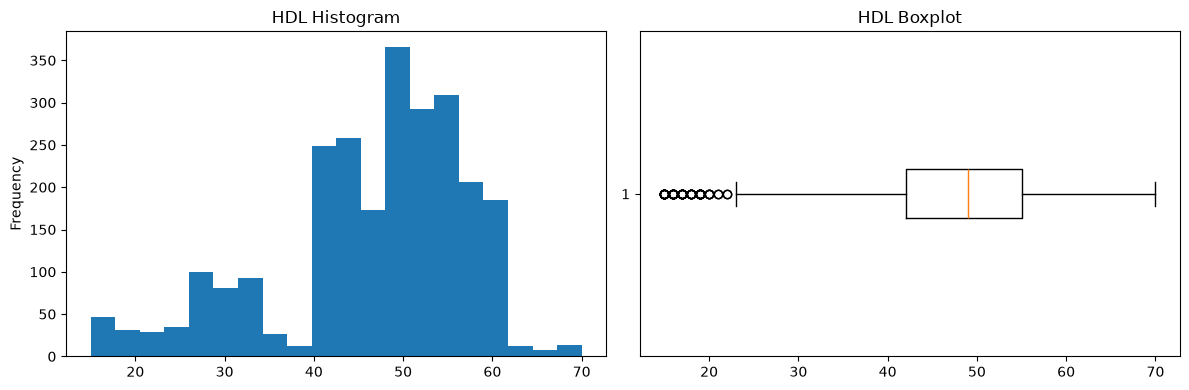

Sys BP


count    1820.000000
mean      135.762088
std        22.742844
min        90.000000
25%       122.000000
50%       132.000000
75%       153.000000
max       185.000000
Name: Sys BP, dtype: float64

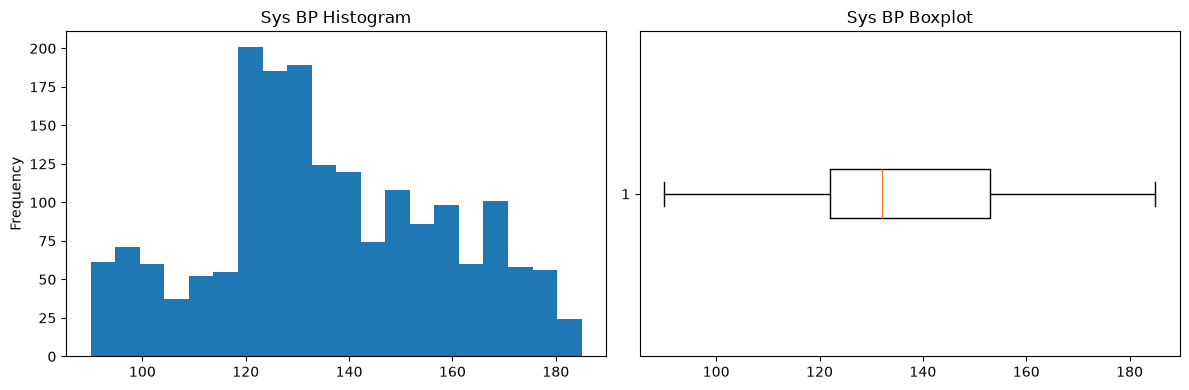

Dia BP


count    3525.000000
mean       81.538156
std        11.379758
min        60.000000
25%        74.000000
50%        81.000000
75%        86.000000
max       124.000000
Name: Dia BP, dtype: float64

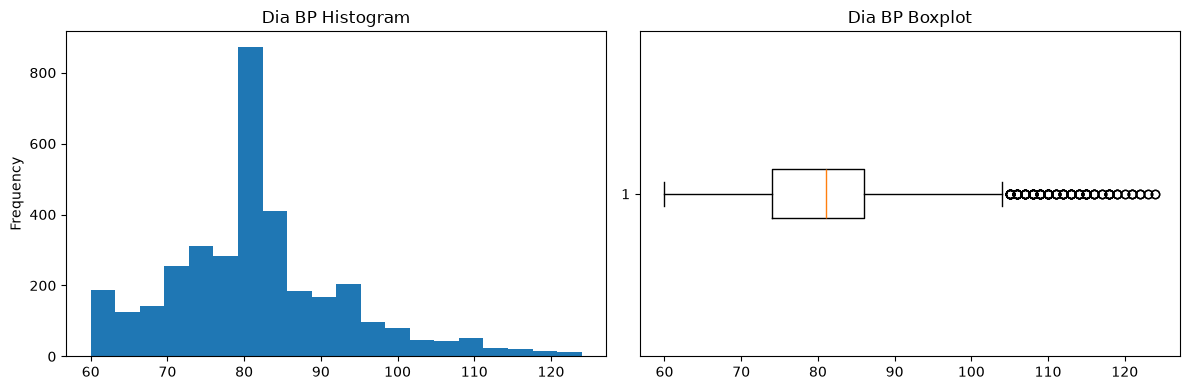

Hemoglobin


count    3525.000000
mean       13.959801
std         1.863969
min         8.800000
25%        12.700000
50%        14.000000
75%        15.000000
max        18.000000
Name: Hemoglobin, dtype: float64

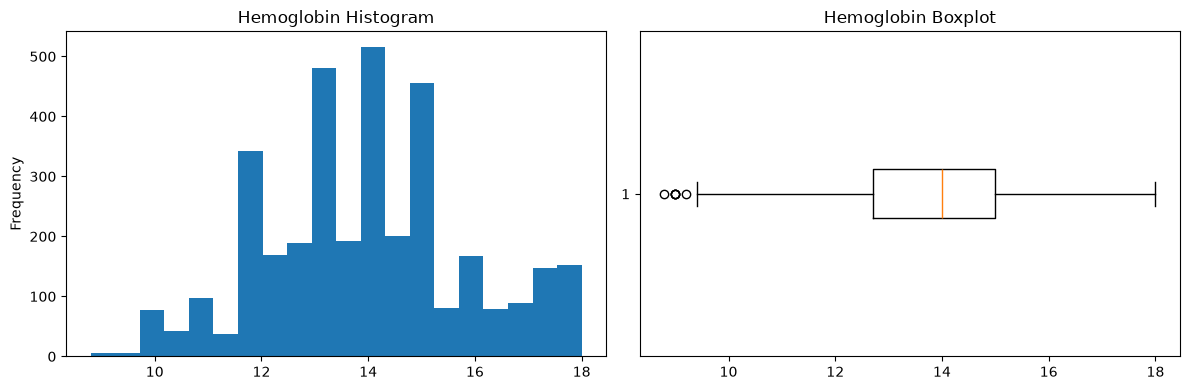

OGTT


count    3012.000000
mean      170.707503
std        48.160549
min        80.000000
25%       142.000000
50%       156.000000
75%       195.000000
max       403.000000
Name: OGTT, dtype: float64

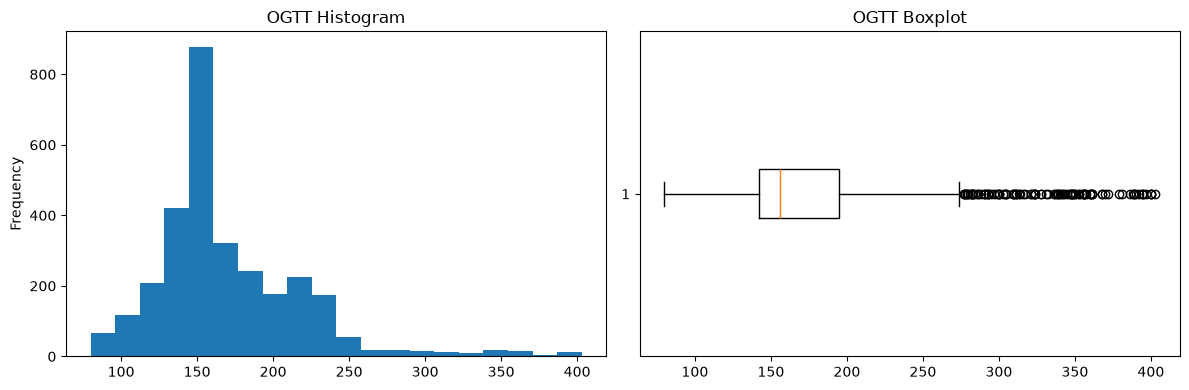

In [4]:
continuous = [
    "Age",
    "BMI",
    "HDL",
    "Sys BP",
    "Dia BP",
    "Hemoglobin",
    "OGTT"
]

for col in continuous:

    print("="*60)
    print(col)

    display(df[col].describe())

    fig, ax = plt.subplots(1,2, figsize=(12,4))

    df[col].plot.hist(ax=ax[0], bins=20)
    ax[0].set_title(f"{col} Histogram")

    ax[1].boxplot(df[col].dropna(), orientation="horizontal")
    ax[1].set_title(f"{col} Boxplot")

    plt.tight_layout()

    plt.show()

## Key Finding 2 — Continuous Variables

Maternal age appears approximately normally distributed with modest variability. BMI demonstrates a right-skewed distribution, indicating a subset of patients with substantially higher body mass index values. HDL and blood pressure measurements show moderate spread with several potential outliers, while OGTT values appear more variable and should be interpreted cautiously given the missing data identified in Notebook 2.

## Investigation 3 — Binary Variables

## Question

How common are each of the binary clinical risk factors?

Family History
0    1769
1    1756
Name: count, dtype: int64

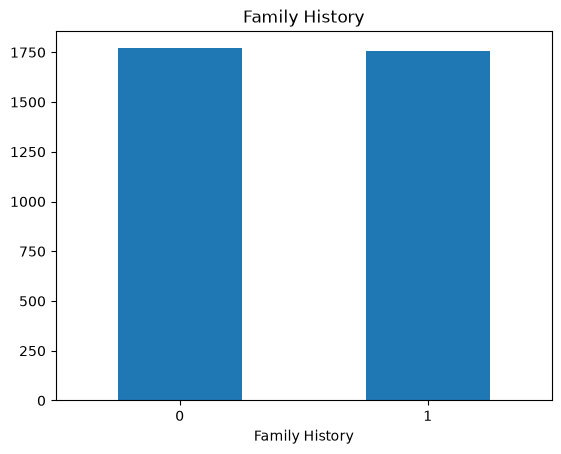

unexplained prenetal loss
0    2239
1    1286
Name: count, dtype: int64

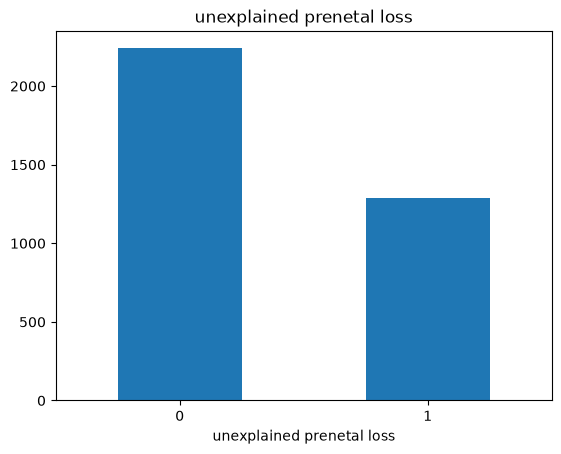

Large Child or Birth Default
0    2264
1    1261
Name: count, dtype: int64

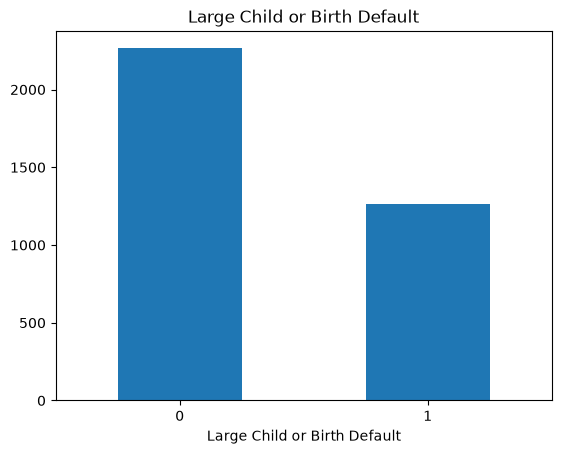

PCOS
0    2592
1     933
Name: count, dtype: int64

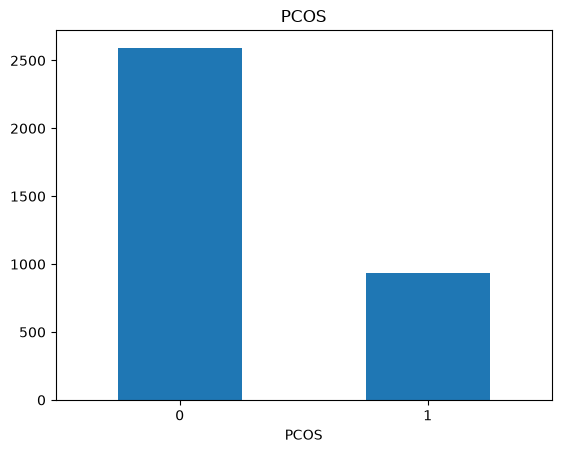

Sedentary Lifestyle
0    1940
1    1585
Name: count, dtype: int64

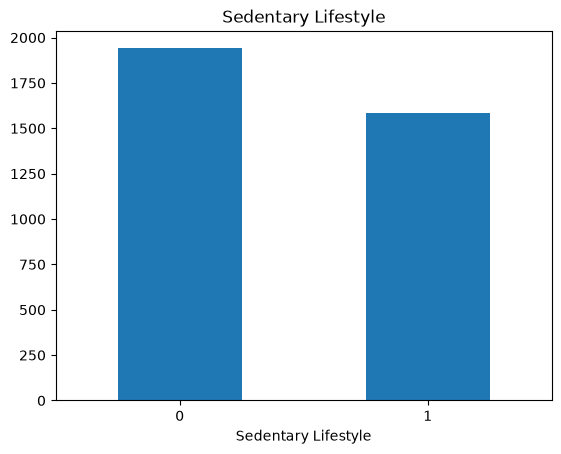

Prediabetes
0    2492
1    1033
Name: count, dtype: int64

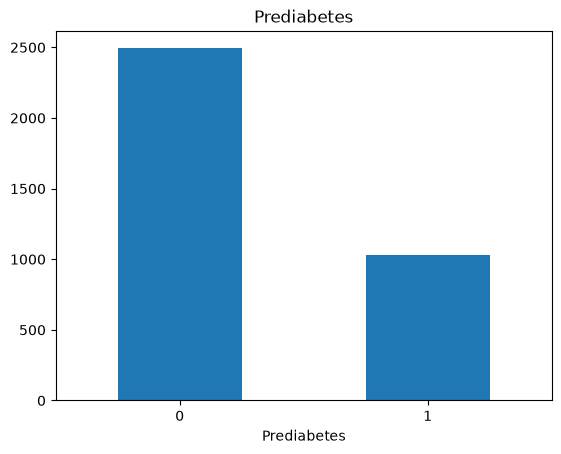

In [5]:
binary = [
    "Family History",
    "unexplained prenetal loss",
    "Large Child or Birth Default",
    "PCOS",
    "Sedentary Lifestyle",
    "Prediabetes"
]

for col in binary:

    counts = df[col].value_counts()

    display(counts)

    counts.plot(kind="bar")

    plt.title(col)

    plt.xticks(rotation=0)

    plt.show()

## Key Finding 3 — Binary Variables

Family history and sedentary lifestyle were among the more common clinical risk factors in the dataset, whereas PCOS and previous unexplained prenatal loss were less prevalent. These differences suggest that certain established risk factors occur relatively infrequently and may contribute more effectively when combined with other predictors rather than considered individually.

## Investigation 4 — Relationship with GDM

## Question

How do predictor variables differ between pregnancies with and without gestational diabetes?

<Figure size 600x400 with 0 Axes>

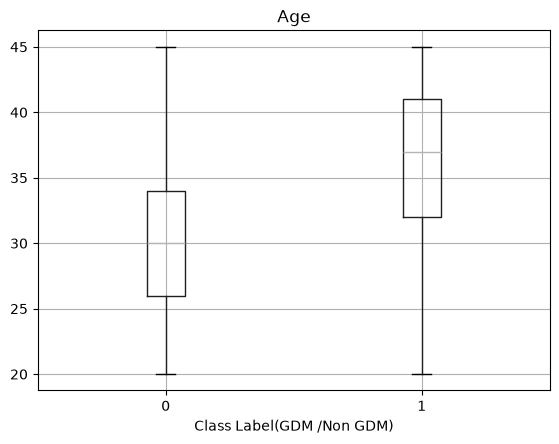

<Figure size 600x400 with 0 Axes>

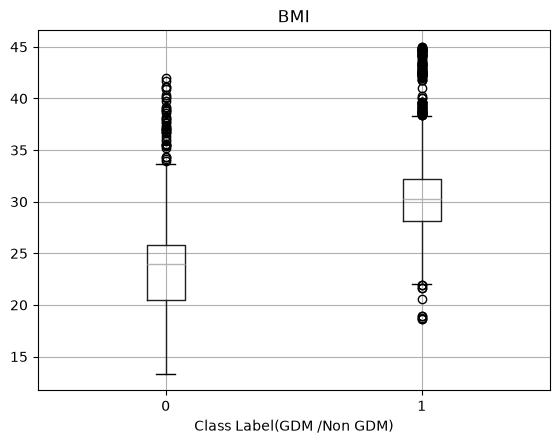

<Figure size 600x400 with 0 Axes>

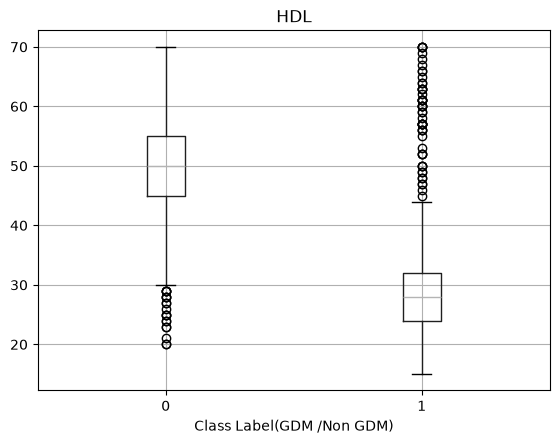

<Figure size 600x400 with 0 Axes>

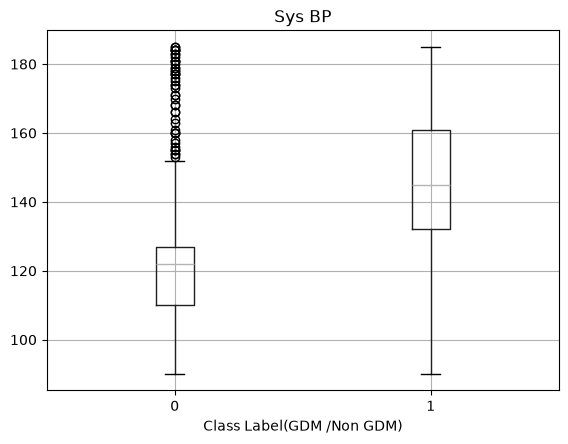

<Figure size 600x400 with 0 Axes>

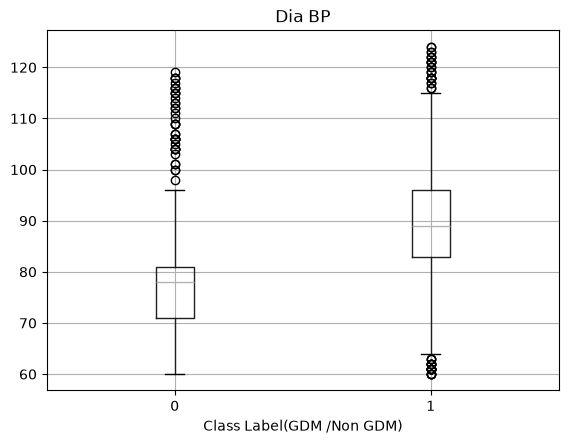

<Figure size 600x400 with 0 Axes>

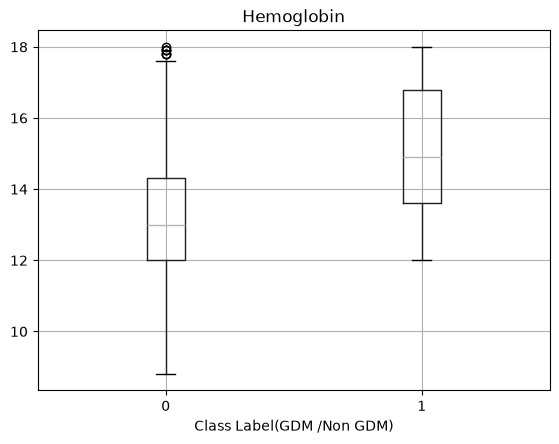

<Figure size 600x400 with 0 Axes>

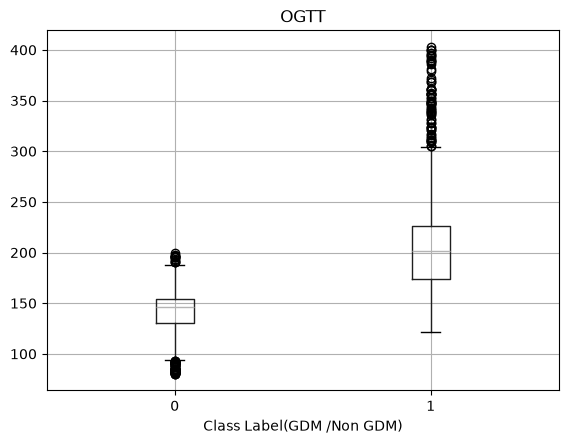

In [6]:
for col in continuous:

    plt.figure(figsize=(6,4))

    df.boxplot(column=col, by=target)

    plt.title(col)

    plt.suptitle("")

    plt.show()

In [7]:
df.groupby(target)[continuous].describe()

Age                                         \
                            count       mean       std   min   25%   50%   
Class Label(GDM /Non GDM)                                                  
0                          2153.0  30.382722  5.216263  20.0  26.0  30.0   
1                          1372.0  36.031341  5.967555  20.0  32.0  37.0   

                                          BMI             ... Hemoglobin  \
                            75%   max   count       mean  ...        75%   
Class Label(GDM /Non GDM)                                 ...              
0                          34.0  45.0  1072.0  23.691418  ...       14.3   
1                          41.0  45.0  1372.0  31.106560  ...       16.8   

                                   OGTT                                       \
                            max   count       mean        std    min     25%   
Class Label(GDM /Non GDM)                                                      
0                          18.0  1640.0  140.32439  19.947971   80.0  130.00   
1                          18.0  1372.0  207.02551  46.840606  122.0  173.75   

                                                
                             50%    75%    max  
Class Label(GDM /Non GDM)                       
0                          146.0  154.0  200.0  
1                          202.0  226.0  403.0  

[2 rows x 56 columns]

In [8]:
for col in binary:

    table = pd.crosstab(
        df[col],
        df[target],
        normalize="columns"
    )

    display(table)

Class Label(GDM /Non GDM),0,1
Family History,,
0,0.639573,0.285714
1,0.360427,0.714286


Class Label(GDM /Non GDM),0,1
unexplained prenetal loss,,
0,0.721319,0.5
1,0.278681,0.5


Class Label(GDM /Non GDM),0,1
Large Child or Birth Default,,
0,0.775197,0.433673
1,0.224803,0.566327


Class Label(GDM /Non GDM),0,1
PCOS,,
0,0.979563,0.352041
1,0.020437,0.647959


Class Label(GDM /Non GDM),0,1
Sedentary Lifestyle,,
0,0.605202,0.464286
1,0.394798,0.535714


Class Label(GDM /Non GDM),0,1
Prediabetes,,
0,0.975848,0.284985
1,0.024152,0.715015


## Key Finding 4 — Relationships with GDM

Pregnancies diagnosed with gestational diabetes generally exhibit higher BMI values than non-GDM pregnancies, although substantial overlap exists between groups. This suggests BMI is likely to contribute predictive value but is unlikely to discriminate perfectly on its own.

## Investigation 5 — Correlation

## Question

How strongly are the continuous predictors related to one another?

In [9]:
corr = df[continuous].corr()

display(corr)

,Age,BMI,HDL,Sys BP,Dia BP,Hemoglobin,OGTT
Age,1.000000,0.516200,-0.444572,0.619515,0.481878,0.288387,0.383144
BMI,0.516200,1.000000,-0.694974,0.245677,0.541788,0.220607,0.758952
HDL,-0.444572,-0.694974,1.000000,-0.629794,-0.581466,-0.125162,-0.697259
Sys BP,0.619515,0.245677,-0.629794,1.000000,0.584059,0.331778,0.322453
Dia BP,0.481878,0.541788,-0.581466,0.584059,1.000000,0.324537,0.460497
Hemoglobin,0.288387,0.220607,-0.125162,0.331778,0.324537,1.000000,0.237489
OGTT,0.383144,0.758952,-0.697259,0.322453,0.460497,0.237489,1.000000


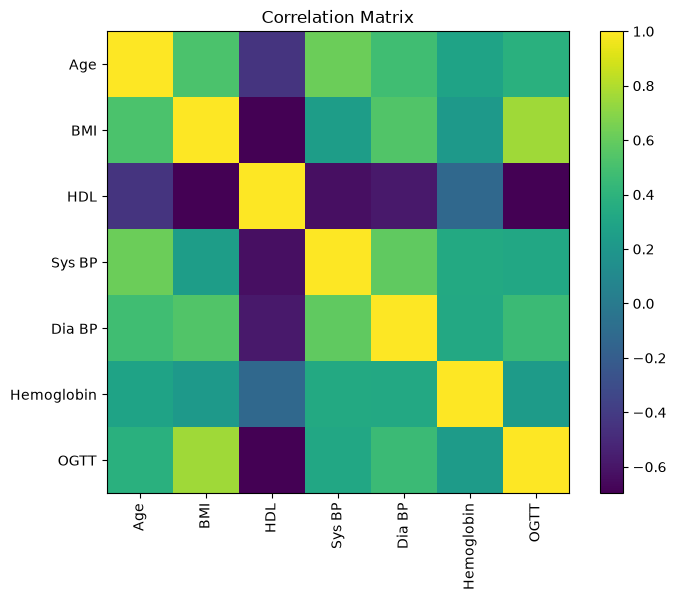

In [10]:
plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

## Key Finding 5 — Correlation Structure

Most continuous predictors exhibit weak to moderate correlations. No pair of variables demonstrates sufficiently strong correlation to immediately suggest problematic multicollinearity. This relationship is expected given the physiological connection between systolic and diastolic blood pressure and does not necessarily indicate problematic multicollinearity.

## Investigation 6 — Missingness and Outcome

## Question

Are patients with missing laboratory values systematically different from those with complete data?

In [11]:
for col in ["BMI","HDL","Sys BP","OGTT"]:

    print(col)

    display(
        pd.crosstab(
            df[col].isna(),
            df[target],
            normalize="index"
        )
    )

BMI


Class Label(GDM /Non GDM),0,1
BMI,,
False,0.438625,0.561375
True,1.000000,0.000000


HDL


Class Label(GDM /Non GDM),0,1
HDL,,
False,0.832409,0.167591
True,0.051948,0.948052


Sys BP


Class Label(GDM /Non GDM),0,1
Sys BP,,
False,0.385165,0.614835
True,0.851613,0.148387


OGTT


Class Label(GDM /Non GDM),0,1
OGTT,,
False,0.544489,0.455511
True,1.000000,0.000000


## Interpretation

Patients with missing laboratory values continue to exhibit different outcome distributions than those with complete measurements. This supports the earlier conclusion that missingness is unlikely to be completely random and should be considered during feature engineering and model development.

## Key Finding 6 — Missingness Patterns

Missing laboratory measurements remain associated with gestational diabetes status. These patterns reinforce observations from the data quality assessment and suggest that missingness itself may contain clinically relevant information rather than representing purely random data loss.

## Summary of Findings

Exploratory analysis identified several clinical variables that demonstrate meaningful associations with gestational diabetes, particularly maternal age, BMI, and OGTT measurements. Although differences between outcome groups were observed, substantial overlap suggests that accurate prediction will require combining multiple predictors within a multivariable model.

Binary clinical risk factors varied considerably in prevalence, with some occurring relatively infrequently. Correlation analysis indicated generally weak to moderate relationships among continuous variables, suggesting that multicollinearity is unlikely to pose a major challenge during initial model development.

Overall, the exploratory analysis demonstrates that the dataset contains clinically meaningful patterns suitable for predictive modeling while highlighting areas for careful feature engineering and preprocessing.

## Next Steps

The insights gained from this exploratory analysis will guide preparation of the modeling dataset.

Planned activities include:

- Reviewing feature selection in light of exploratory findings.
- Applying feature scaling where appropriate.
- Constructing a stratified train-test split.
- Building reproducible preprocessing pipelines.
- Developing and evaluating a baseline Logistic Regression model.